[12/11 16:40:50] All statistics calculated. Creating matrix pool manager...


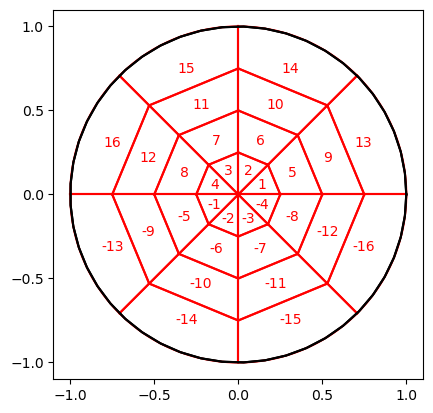

In [1]:
import numpy as np
import cupy as cp
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
)
from random_matrix.input_statistics.density_function import (
    DensityFunctionTerm,
)
import multiprocess as mp
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
import h5py
from random_matrix.utils import matrix_utils
from random_matrix.modes import mode_grid_factory
import traceback
import os
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Simulation parameters
# -----------------------------------------------------------------------------

wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17

medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})
particle_statistics = ParticleStatistics(
    term,
    isotropic_sphere.get_A,
    isotropic_sphere.get_A_product,
    isotropic_sphere.get_A_product_conj,
)
medium_statistics = MediumStatistics([particle_statistics])
integration_task_config = IntegrationTaskConfig(integration_method="lattice")

side_lengths = [0.5]
my_grid = mode_grid_factory.from_dr_dt(
    0.25, 2 * np.pi / 8, 1.0, False, 0.0, True, False
)
my_grid.plot(show_indices=True)

ism = InputStatisticsManager(
    "cascade_test",
    medium_parameters,
    medium_statistics,
    my_grid,
    integration_task_config,
)
mpm = ism.get_matrix_pool_manager()
# print("Finishing...")


In [2]:
mpm.load_single_pool_S()

Loading statistics...
Loaded. Generating matrices...


In [4]:
def test_function(matrix):
    xp = cp.get_array_module(matrix)
    t = matrix_utils.get_block(matrix, "t")
    eigvals = xp.linalg.eigvalsh(t@xp.conj(t).T)
    return xp.mean(eigvals)


analysis_functions = {"mean_eig": test_function}
cascade_name = "df"
num_samples = 1000
analysis_points = [1, 50, 100,200,500,1000]
use_transfer_matrices = False
use_multi_pool = False
mpm.load_single_pool_S()
mpm.cascade_hdf5_depth_first(
    cascade_name,
    num_samples,
    analysis_points,
    analysis_functions,
    use_transfer_matrices,
    use_multi_pool,
    use_cupy=False
)

100%|██████████| 1000/1000 [23:05<00:00,  1.39s/it]


In [ ]:
assert False

In [ ]:
def test_function(matrices):
    ts = matrix_utils.get_block(matrices, "t")
    data = []
    for t in ts:
        eigvals = np.linalg.eigvals(t@np.conj(t).T)
        data.append(np.mean(eigvals))
    return np.array(data)


analysis_functions = {"mean_eig": test_function}
cascade_name = "bf"
num_samples = 100
analysis_points = [1, 50, 100,200,500,1000]
use_transfer_matrices = False
use_multi_pool = False
mpm.load_single_pool_S()
mpm.cascade_hdf5(
    cascade_name,
    num_samples,
    1000,
    analysis_points,
    analysis_functions,
    use_transfer_matrices,
    use_multi_pool,
)

  0%|          | 1/1000 [00:00<03:38,  4.58it/s]

  5%|▌         | 50/1000 [00:05<02:17,  6.91it/s]

 10%|█         | 100/1000 [00:11<02:11,  6.85it/s]

 20%|██        | 200/1000 [00:22<02:00,  6.62it/s]

 48%|████▊     | 476/1000 [00:54<00:59,  8.79it/s]


KeyboardInterrupt: 

In [ ]:
def test_function(matrix):
    t = matrix_utils.get_block(matrix, "t")
    eigvals = np.linalg.eigvalsh(t@np.conj(t).T)
    return np.mean(eigvals)


analysis_functions = {"mean_eig": test_function}
cascade_name = "df"
num_samples = 100
analysis_points = [1, 50, 100,200,500,1000]
use_transfer_matrices = False
use_multi_pool = False
mpm.load_single_pool_S()
mpm.cascade_hdf5_depth_first(
    cascade_name,
    num_samples,
    analysis_points,
    analysis_functions,
    use_transfer_matrices,
    use_multi_pool,
)

100%|██████████| 100/100 [01:56<00:00,  1.16s/it]


In [ ]:
ass

/home/nbyrnes/.conda/envs/random_matrix/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


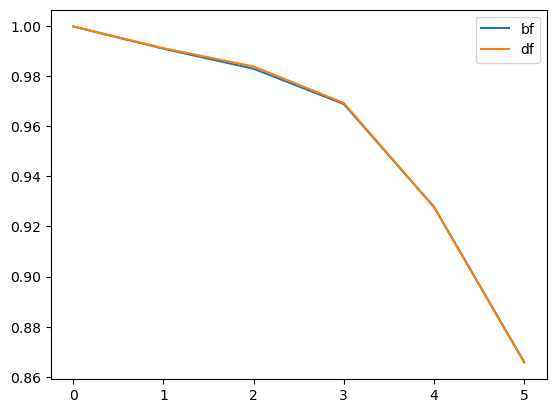

In [ ]:
# Test the results from cascade_hdf5
# Test the results from cascade_hdf5
with h5py.File("/home/nbyrnes/code/random-matrix/data/cascade_test/cascades/bf.h5","r") as f:
    data_bf = f["mean_eig"][:]
with h5py.File("/home/nbyrnes/code/random-matrix/data/cascade_test/cascades/df.h5","r") as f:
    data_df = f["mean_eig"][:]

fig, ax = plt.subplots()
xs = range(len(data_bf))

ys_bf = [np.mean(d) for d in data_bf]
ys_df = [np.mean(d) for d in data_df]

ax.plot(xs,ys_bf,label="bf")
ax.plot(xs,ys_df,label="df")
ax.legend()

In [ ]:
assert False

In [ ]:
cp.linalg.eigvalsh

<function cupy.linalg._eigenvalue.eigvalsh(a, UPLO='L')>

In [ ]:
def test_function(matrix):
    t = matrix_utils.get_block(matrix, "t")
    eigvals = cp.linalg.eigvals(t@np.conj(t).T)
    return cp.mean(eigvals)


analysis_functions = {"mean_eig": test_function}
cascade_name = "df"
num_samples = 100
analysis_points = [1, 50, 100,200,500,1000]
use_transfer_matrices = False
use_multi_pool = False
mpm.load_single_pool_S()
mpm.cascade_hdf5_depth_first(
    cascade_name,
    num_samples,
    analysis_points,
    analysis_functions,
    use_transfer_matrices,
    use_multi_pool,
    use_cupy=True
)